In [6]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)

# -----------------------------
# 1. CONFIG
# -----------------------------
cities = ["City_A", "City_B", "City_C"]
categories = ["Luxury", "Standard"]
days = 450
start_date = datetime(2023, 1, 1)

# -----------------------------
# 2. CITY PROFILES (CRITICAL FIX)
# -----------------------------
city_profiles = {
    "City_A": {"wealth": 1.0, "luxury_sensitivity": 1.0},
    "City_B": {"wealth": 1.3, "luxury_sensitivity": 1.5},
    "City_C": {"wealth": 0.7, "luxury_sensitivity": 0.6}
}

# -----------------------------
# 3. GENERATE ECONOMIC SERIES
# -----------------------------
economic_data = {}

for city in cities:
    profile = city_profiles[city]

    base_income = np.random.randint(30000, 70000) * profile["wealth"]
    base_price = np.random.randint(200000, 600000) * profile["wealth"]

    income_series = []
    price_series = []

    for d in range(days):
        # Smooth trend
        income_trend = base_income + d * np.random.uniform(10, 25)
        price_trend = base_price + d * np.random.uniform(80, 250)

        # Occasional spikes (growth events)
        spike_income = np.random.choice(
            [0, np.random.uniform(5000, 20000)], p=[0.9, 0.1]
        )
        spike_price = np.random.choice(
            [0, np.random.uniform(20000, 100000)], p=[0.9, 0.1]
        )

        income = income_trend + spike_income + np.random.normal(0, 1500)
        price = price_trend + spike_price + np.random.normal(0, 8000)

        income_series.append(max(1000, income))
        price_series.append(max(50000, price))

    economic_data[city] = {
        "income": income_series,
        "price": price_series
    }

# -----------------------------
# 4. BUILD FINAL DATASET
# -----------------------------
rows = []

for city in cities:
    profile = city_profiles[city]
    income_series = economic_data[city]["income"]
    price_series = economic_data[city]["price"]

    for d in range(days):
        date = start_date + timedelta(days=d)

        for category in categories:

            income = income_series[d]
            price = price_series[d]

            # -----------------------------
            # DATE FEATURES
            # -----------------------------
            day_of_year = date.timetuple().tm_yday
            month = date.month

            # -----------------------------
            # VELOCITY FEATURES
            # -----------------------------
            if d >= 30:
                income_velocity = (income - income_series[d-30]) / income_series[d-30]
                price_velocity = (price - price_series[d-30]) / price_series[d-30]
            else:
                income_velocity = 0
                price_velocity = 0

            affordability = price / income

            # -----------------------------
            # STABILITY FEATURE
            # -----------------------------
            rolling_units = np.random.uniform(5, 20)

            # -----------------------------
            # SURGE LOGIC (NON-LINEAR + CITY + CATEGORY)
            # -----------------------------
            velocity_score = 0.6 * income_velocity + 0.4 * price_velocity

            if velocity_score <= 0:
                extra_units = 0
            elif velocity_score < 0.03:
                extra_units = 0
            elif velocity_score < 0.08:
                extra_units = velocity_score * 20
            else:
                extra_units = (velocity_score ** 2) * 220

            # Category effect
            if category == "Luxury":
                extra_units *= 1.5
            else:
                extra_units *= 0.3

            # City effect (CRITICAL)
            extra_units *= profile["luxury_sensitivity"]
            extra_units += profile["wealth"] * 2

            # Add noise (prevents trivial learning)
            extra_units += np.random.normal(0, 2)

            # Clamp values
            extra_units = max(0, extra_units)
            extra_units = min(50, extra_units)

            rows.append([
                date,
                city,
                category,
                day_of_year,
                month,
                income,
                price,
                affordability,
                income_velocity,
                price_velocity,
                rolling_units,
                extra_units
            ])

df = pd.DataFrame(rows, columns=[
    "date", "city", "category",
    "day_of_year", "month",
    "median_income", "median_home_price",
    "affordability_ratio",
    "income_velocity_30d", "price_velocity_30d",
    "rolling_units_30d",
    "extra_units_sold"
])

# -----------------------------
# 5. ENCODING
# -----------------------------
df_encoded = pd.get_dummies(df, columns=["city", "category"], drop_first=True)

print(df.head())
print("\nDataset Shape:", df.shape)

# Save if needed
df.to_csv("luxury_surge_dataset.csv", index=False)

        date    city  category  day_of_year  month  median_income  \
0 2023-01-01  City_A    Luxury            1      1   44467.154481   
1 2023-01-01  City_A  Standard            1      1   44467.154481   
2 2023-01-02  City_A    Luxury            2      1   63838.312092   
3 2023-01-02  City_A  Standard            2      1   63838.312092   
4 2023-01-03  City_A    Luxury            3      1   45438.646037   

   median_home_price  affordability_ratio  income_velocity_30d  \
0      328634.492156             7.390500                  0.0   
1      328634.492156             7.390500                  0.0   
2      364393.610977             5.708071                  0.0   
3      364393.610977             5.708071                  0.0   
4      354522.157350             7.802217                  0.0   

   price_velocity_30d  rolling_units_30d  extra_units_sold  
0                 0.0           9.753283          0.000000  
1                 0.0           6.842600          0.000000  
2    


===== BASIC INFO =====
       day_of_year        month  median_income  median_home_price  \
count  2700.000000  2700.000000    2700.000000        2700.000000   
mean    156.555556     5.657778   50560.150044      399142.085897   
std     110.118443     3.606619   15189.805607       52778.532822   
min       1.000000     1.000000   25726.917383      299724.501341   
25%      57.000000     2.000000   34436.218968      354563.370426   
50%     140.500000     5.000000   50049.899295      391525.001858   
75%     253.000000     9.000000   64940.828054      438097.631981   
max     365.000000    12.000000   95399.816466      577935.990034   

       affordability_ratio  income_velocity_30d  price_velocity_30d  \
count          2700.000000          2700.000000         2700.000000   
mean              8.986089             0.018240            0.015529   
std               3.909027             0.123009            0.076849   
min               3.859584            -0.413428           -0.269069   

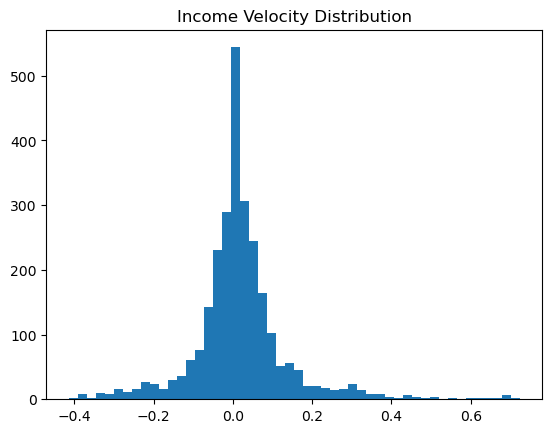


City-wise Demand:
city
City_A    2.947371
City_B    3.534563
City_C    2.604595
Name: extra_units_sold, dtype: float64

Category-wise Demand:
category
Luxury      3.594824
Standard    2.462863
Name: extra_units_sold, dtype: float64

High Velocity Mean Demand: 6.697894723201505
Overall Mean Demand: 3.028843193152222


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("luxury_surge_dataset.csv")

print("\n===== BASIC INFO =====")
print(df.describe())

# -----------------------------
# 1. CHECK TARGET RANGE
# -----------------------------
print("\nTarget Range:")
print(df["extra_units_sold"].min(), df["extra_units_sold"].max())

# -----------------------------
# 2. VELOCITY DISTRIBUTION
# -----------------------------
plt.hist(df["income_velocity_30d"], bins=50)
plt.title("Income Velocity Distribution")
plt.show()

# -----------------------------
# 3. CITY EFFECT
# -----------------------------
print("\nCity-wise Demand:")
print(df.groupby("city")["extra_units_sold"].mean())

# -----------------------------
# 4. CATEGORY EFFECT
# -----------------------------
print("\nCategory-wise Demand:")
print(df.groupby("category")["extra_units_sold"].mean())

# -----------------------------
# 5. SURGE CHECK
# -----------------------------
high_velocity = df[df["income_velocity_30d"] > 0.1]

print("\nHigh Velocity Mean Demand:", high_velocity["extra_units_sold"].mean())
print("Overall Mean Demand:", df["extra_units_sold"].mean())

Dataset Shape: (2700, 12)
         date    city  category  day_of_year  month  median_income  \
0  2023-01-01  City_A    Luxury            1      1   44467.154481   
1  2023-01-01  City_A  Standard            1      1   44467.154481   
2  2023-01-02  City_A    Luxury            2      1   63838.312092   
3  2023-01-02  City_A  Standard            2      1   63838.312092   
4  2023-01-03  City_A    Luxury            3      1   45438.646037   

   median_home_price  affordability_ratio  income_velocity_30d  \
0      328634.492156             7.390500                  0.0   
1      328634.492156             7.390500                  0.0   
2      364393.610977             5.708071                  0.0   
3      364393.610977             5.708071                  0.0   
4      354522.157350             7.802217                  0.0   

   price_velocity_30d  rolling_units_30d  extra_units_sold  
0                 0.0           9.753283          0.000000  
1                 0.0           6.

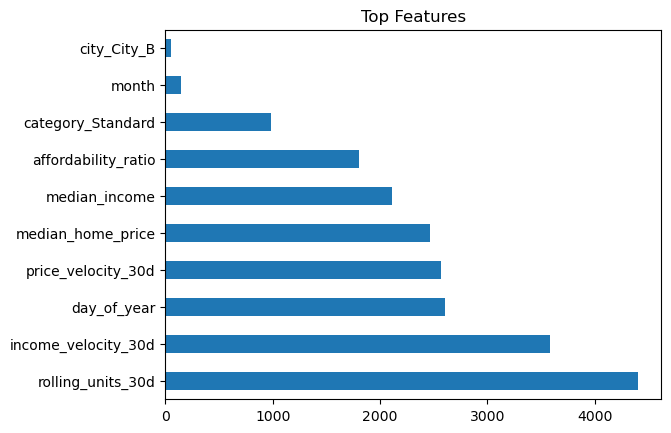

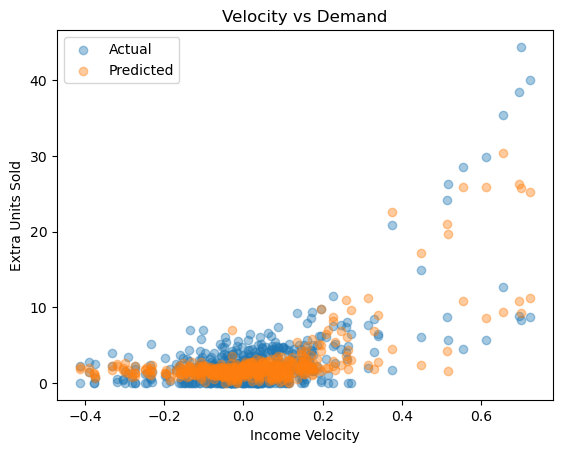


===== CATEGORY EFFECT =====
                     actual  predicted
category_Standard                     
False              3.293713   3.074810
True               2.082036   1.758942

===== CITY EFFECT =====
          actual  predicted
city                       
City_C  2.687874   2.416876

===== HIGH VELOCITY CHECK =====
Actual: 5.753750157297501
Pred  : 5.019398923594732

===== MANUAL SPIKE TEST =====
Predicted uplift: 14.168323791638615


In [9]:
# ============================================
# 1. IMPORTS
# ============================================
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# ============================================
# 2. LOAD DATA
# ============================================
df = pd.read_csv("luxury_surge_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ============================================
# 3. ENCODING
# ============================================
df_encoded = pd.get_dummies(df, columns=["city", "category"], drop_first=True)

# ============================================
# 4. FEATURE / TARGET SPLIT
# ============================================
X = df_encoded.drop(["date", "extra_units_sold"], axis=1)
y = df_encoded["extra_units_sold"]

# ============================================
# 5. TIME-BASED TRAIN TEST SPLIT
# ============================================
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# ============================================
# 6. MODEL (UPDATED)
# ============================================
model = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.025,
    max_depth=10,
    min_child_samples=10,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# ============================================
# 7. SAMPLE WEIGHTS (FOCUS ON SPIKES)
# ============================================
sample_weights = 1 + (X_train["income_velocity_30d"] > 0.1) * 2

# ============================================
# 8. TRAINING
# ============================================
model.fit(X_train, y_train, sample_weight=sample_weights)

# ============================================
# 9. PREDICTION
# ============================================
preds = model.predict(X_test)

# Clamp predictions
preds = np.clip(preds, 0, 50)

# ============================================
# 10. METRICS
# ============================================
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("\n===== MODEL PERFORMANCE =====")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

# ============================================
# 11. FEATURE IMPORTANCE
# ============================================
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(importances)

importances.head(10).plot(kind="barh", title="Top Features")
plt.show()

# ============================================
# 12. BEHAVIOR CHECK (VELOCITY)
# ============================================
plt.scatter(X_test["income_velocity_30d"], y_test, alpha=0.4, label="Actual")
plt.scatter(X_test["income_velocity_30d"], preds, alpha=0.4, label="Predicted")
plt.xlabel("Income Velocity")
plt.ylabel("Extra Units Sold")
plt.legend()
plt.title("Velocity vs Demand")
plt.show()

# ============================================
# 13. CATEGORY CHECK
# ============================================
df_test = X_test.copy()
df_test["actual"] = y_test
df_test["predicted"] = preds

print("\n===== CATEGORY EFFECT =====")
print(df_test.groupby("category_Standard")[["actual", "predicted"]].mean())

# ============================================
# 14. CITY CHECK
# ============================================
df_test["city"] = "City_A"
df_test.loc[df_test["city_City_B"] == 1, "city"] = "City_B"
df_test.loc[df_test["city_City_C"] == 1, "city"] = "City_C"

print("\n===== CITY EFFECT =====")
print(df_test.groupby("city")[["actual", "predicted"]].mean())

# ============================================
# 15. HIGH VELOCITY CHECK
# ============================================
high_vel = X_test["income_velocity_30d"] > 0.1

print("\n===== HIGH VELOCITY CHECK =====")
print("Actual:", y_test[high_vel].mean())
print("Pred  :", preds[high_vel].mean())

# ============================================
# 16. MANUAL SPIKE TEST (FIXED WARNING)
# ============================================
sample = X_test.iloc[0].copy()

sample["income_velocity_30d"] = 0.25
sample["price_velocity_30d"] = 0.2

sample_df = pd.DataFrame([sample], columns=X.columns)

print("\n===== MANUAL SPIKE TEST =====")
print("Predicted uplift:", model.predict(sample_df)[0])

In [10]:
def predict_uplift(model, input_dict, X_columns):
    import pandas as pd

    df = pd.DataFrame([input_dict])
    df = pd.get_dummies(df)

    # Align columns
    df = df.reindex(columns=X_columns, fill_value=0)

    pred = model.predict(df)[0]
    return max(0, min(50, pred))